# Probability of default model

This notebook compares a binned logistic regression scorecard with a tree model for predicting 90+ days past due within the first 12 EMIs. It uses a forward-in-time validation cohort, keeps applicants out of both sides of the split, reports discrimination and calibration, explains model drivers, and writes `predictions_test.csv`.


In [5]:
from pathlib import Path
import sys

project_root = next(
    (path for path in [Path.cwd(), *Path.cwd().parents] if (path / "src" / "target.py").is_file()),
    None,
)
if project_root is None:
    raise FileNotFoundError("Run this notebook from the project or its notebooks folder.")
sys.path.insert(0, str(project_root))

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import KBinsDiscretizer, OneHotEncoder
from xgboost import XGBClassifier

from src.features import prepare_features
from src.target import build_target, parse_dates


## Build the observed target

The target is a 90+ DPD event during the first 12 EMIs. Loans without 12 observed EMIs are excluded because their outcomes are not yet fully known.


In [6]:
apps = pd.read_csv(project_root / "data" / "loan_applications.csv")
repayments = pd.read_csv(project_root / "data" / "repayment_history.csv")

targets = build_target(repayments, as_of="2026-08-31")
data = apps.merge(targets, on="application_id", how="inner")
data = data.loc[data["is_fully_observed"]].copy()
data["_application_date"] = parse_dates(data["application_date"], "application_date")
data = data.sort_values("_application_date").reset_index(drop=True)

print(f"Observed applications: {len(data):,}")
print(f"Observed bad rate: {data['default_90dpd_12m'].mean():.3%}")
print(f"Date range: {data['_application_date'].min().date()} to {data['_application_date'].max().date()}")


Observed applications: 14,863
Observed bad rate: 10.274%
Date range: 2024-01-01 to 2025-08-29


## Forward-time validation and repeated applicants

A random row split can train on later vintages and validate on earlier ones, hiding changes in applicant mix, policy, sourcing, or the economy. It can also put loans from one applicant in both sets, letting applicant-specific patterns leak across the split.

Validation uses applications from 2025-04-01 onward. To prevent applicant overlap, earlier applications from any applicant in that future cohort are removed from training. This evaluates later applications from applicants absent from model fitting; multiple loans within the validation cohort remain separate application decisions.


In [7]:
cutoff = pd.Timestamp("2025-04-01")
val = data.loc[data["_application_date"] >= cutoff].copy()
train_candidates = data.loc[data["_application_date"] < cutoff].copy()
val_applicants = set(val["applicant_id"].dropna())
train = train_candidates.loc[~train_candidates["applicant_id"].isin(val_applicants)].copy()

assert set(train["applicant_id"].dropna()).isdisjoint(val_applicants)
# Keep the parsed date only for splitting; it is not an application-time predictor.
train = train.drop(columns="_application_date")
val = val.drop(columns="_application_date")
if train.empty or val.empty:
    raise ValueError("The time split produced an empty training or validation set.")

print(f"Training:   {len(train):,} rows | bad rate {train['default_90dpd_12m'].mean():.3%}")
print(f"Validation: {len(val):,} rows | bad rate {val['default_90dpd_12m'].mean():.3%}")
print(f"Applicants shared across sets: {len(set(train['applicant_id']) & set(val['applicant_id']))}")
print(f"Earlier rows purged for applicant overlap: {len(train_candidates) - len(train):,}")


Training:   13,791 rows | bad rate 10.565%
Validation: 988 rows | bad rate 5.972%
Applicants shared across sets: 0
Earlier rows purged for applicant overlap: 84


## Application-time features and models

Identifiers, gender, repayment outcomes, post-application fields, and granular city/pincode fields are excluded from predictors. The logistic regression scorecard bins continuous numeric features into five quantile bins and one-hot encodes categories, so coefficients map to readable feature bins and categories. The tree model uses numeric values and one-hot encoded categories.


In [8]:
TARGET = "default_90dpd_12m"
train_features = prepare_features(train)
val_features = prepare_features(val)
feature_cols = [c for c in train_features.columns if c not in {"city", "pincode"}]

# Use the training schema for validation, preserving a consistent feature order.
X_train = train_features[feature_cols]
X_val = val_features[feature_cols]
y_train = train[TARGET].astype(int)
y_val = val[TARGET].astype(int)

cat_cols = [c for c in feature_cols if not pd.api.types.is_numeric_dtype(train_features[c])]
binary_cols = [c for c in feature_cols if c in {"is_new_to_credit", "foir_above_100", "has_coapplicant"}]
# Month is categorical to avoid imposing a linear month-to-risk relationship.
if "application_month" in feature_cols:
    binary_cols.append("application_month")
cat_cols = list(dict.fromkeys(cat_cols + binary_cols))
num_cols = [c for c in feature_cols if c not in cat_cols]

lr_preprocessor = ColumnTransformer([
    ("bins", Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("bin", KBinsDiscretizer(n_bins=5, encode="onehot", strategy="quantile")),
    ]), num_cols),
    ("categories", Pipeline([
        ("impute", SimpleImputer(strategy="constant", fill_value="Unknown")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]), cat_cols),
])
tree_preprocessor = ColumnTransformer([
    ("numeric", SimpleImputer(strategy="median"), num_cols),
    ("categories", Pipeline([
        ("impute", SimpleImputer(strategy="constant", fill_value="Unknown")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]), cat_cols),
])

lr_model = Pipeline([
    ("prep", lr_preprocessor),
    ("model", LogisticRegression(max_iter=2000, random_state=42)),
])
tree_model = Pipeline([
    ("prep", tree_preprocessor),
    ("model", XGBClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=4,
        subsample=0.9, colsample_bytree=0.9,
        eval_metric="logloss", random_state=42, n_jobs=4,
    )),
])

lr_model.fit(X_train, y_train)
tree_model.fit(X_train, y_train)
lr_pd = lr_model.predict_proba(X_val)[:, 1]
tree_pd = tree_model.predict_proba(X_val)[:, 1]
print(f"Features: {len(feature_cols)} raw ({len(num_cols)} numeric, {len(cat_cols)} categorical/binary)")


c:\Coding Folders\hilbit_ai_assignment\.venv\Lib\site-packages\sklearn\preprocessing\_discretization.py:385: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(
c:\Coding Folders\hilbit_ai_assignment\.venv\Lib\site-packages\sklearn\preprocessing\_discretization.py:385: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 5 are removed. Consider decreasing the number of bins.
  warnings.warn(
c:\Coding Folders\hilbit_ai_assignment\.venv\Lib\site-packages\sklearn\preprocessing\_discretization.py:385: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 6 are removed. Consider decreasing the number of bins.
  warnings.warn(
c:\Coding Folders\hilbit_ai_assignment\.venv\Lib\site-packages\sklearn\preprocessing\_discretization.py:385: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 11 are removed. Consider decreasing the number of bins.
  warnin

Features: 27 raw (16 numeric, 11 categorical/binary)


## Validation metrics

AUC measures ranking; Gini is `2 * AUC - 1`. KS is the maximum separation between the bad and good score distributions. Calibration below compares average predicted PD with the observed bad rate in each predicted-PD decile.


In [9]:
def validation_metrics(y_true, pd_scores):
    auc = roc_auc_score(y_true, pd_scores)
    fpr, tpr, _ = roc_curve(y_true, pd_scores)
    return {"AUC": auc, "Gini": 2 * auc - 1, "KS": float(np.max(tpr - fpr))}

metrics = pd.DataFrame({
    name: validation_metrics(y_val, scores)
    for name, scores in [("Binned logistic regression", lr_pd), ("Tree model", tree_pd)]
}).T
print(metrics.round(4).to_string())

def calibration_by_decile(y_true, pd_scores, model_name):
    frame = pd.DataFrame({"actual": np.asarray(y_true), "predicted_pd": pd_scores})
    frame["decile"] = pd.qcut(frame["predicted_pd"].rank(method="first"), 10, labels=False) + 1
    result = frame.groupby("decile", observed=True).agg(
        applications=("actual", "size"),
        mean_predicted_pd=("predicted_pd", "mean"),
        actual_bad_rate=("actual", "mean"),
    ).reset_index()
    result.insert(0, "model", model_name)
    return result

calibration = pd.concat([
    calibration_by_decile(y_val, lr_pd, "Binned logistic regression"),
    calibration_by_decile(y_val, tree_pd, "Tree model"),
], ignore_index=True)
print(calibration.round(4).to_string(index=False))


                               AUC    Gini      KS
Binned logistic regression  0.6277  0.2554  0.2232
Tree model                  0.6872  0.3744  0.3421
                     model  decile  applications  mean_predicted_pd  actual_bad_rate
Binned logistic regression       1            99             0.0171           0.0404
Binned logistic regression       2            99             0.0299           0.0505
Binned logistic regression       3            99             0.0403           0.0303
Binned logistic regression       4            98             0.0531           0.0306
Binned logistic regression       5            99             0.0679           0.0303
Binned logistic regression       6            99             0.0875           0.0707
Binned logistic regression       7            98             0.1077           0.0714
Binned logistic regression       8            99             0.1366           0.0606
Binned logistic regression       9            99             0.1823           0.07

## Global feature importance

Mean absolute SHAP values summarize the tree model's average contribution to its predictions. One-hot columns are combined back to their original application feature for this global view.


              feature  mean_abs_shap
   bureau_score_clean        0.38774
             foir_pct        0.26016
            dealer_id        0.23491
      occupation_type        0.22370
              ltv_pct        0.12290
bureau_vintage_months        0.11209
    income_proof_type        0.10005
     sourcing_channel        0.09553
    application_month        0.08712
    enquiries_last_6m        0.07911
       monthly_income        0.07537
       residence_type        0.06743
      has_coapplicant        0.06498
    interest_rate_pct        0.05736
        on_road_price        0.04040
         down_payment        0.03747
                  age        0.03628
            city_tier        0.03362
                  emi        0.03189
         existing_emi        0.02900


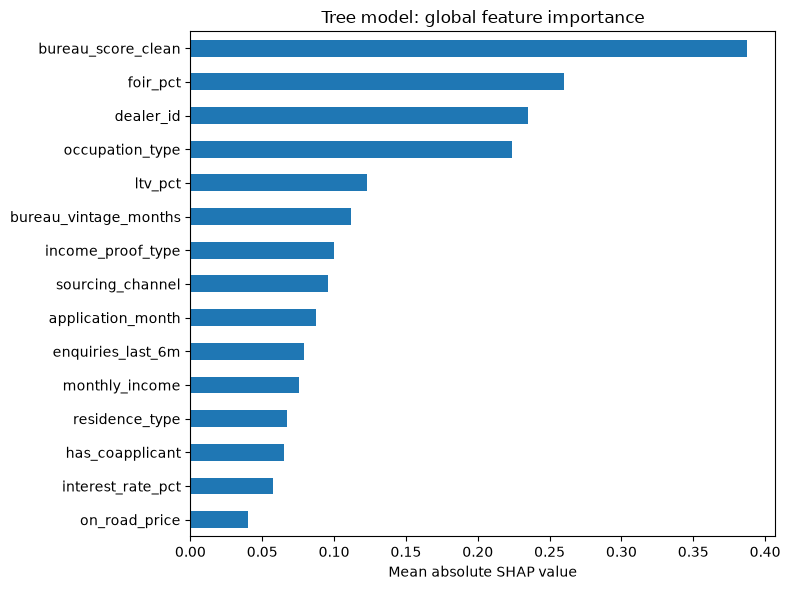


Binned logistic scorecard: strongest terms (positive coefficient raises modeled odds):
                               term  coefficient
       categories__dealer_id_DLR317       2.6168
       categories__dealer_id_DLR388       2.4559
       categories__dealer_id_DLR451       1.9023
       categories__dealer_id_DLR342       1.8957
       categories__dealer_id_DLR356      -0.8876
       categories__dealer_id_DLR449      -0.8540
       bins__bureau_score_clean_4.0      -0.7844
       categories__dealer_id_DLR357      -0.7685
       categories__dealer_id_DLR300      -0.6771
       categories__dealer_id_DLR394      -0.6560
       categories__dealer_id_DLR320       0.6512
       categories__dealer_id_DLR404      -0.6297
       categories__dealer_id_DLR323      -0.6201
       categories__dealer_id_DLR413       0.6198
       categories__dealer_id_DLR375      -0.6066
       categories__dealer_id_DLR307      -0.6039
       categories__dealer_id_DLR456       0.6009
       categories__dealer_id_D

In [10]:
import shap

def encoded_feature_groups(preprocessor, numeric_columns, categorical_columns):
    names = preprocessor.get_feature_names_out()
    groups = []
    for name in names:
        clean = name.split("__", 1)[-1]
        # Match the longest original feature prefix so names such as
        # bureau_score_clean and foir_above_100 remain intact.
        candidates = list(numeric_columns) + list(categorical_columns)
        matches = [c for c in candidates if clean == c or clean.startswith(c + "_")]
        groups.append(max(matches, key=len) if matches else clean)
    return names, groups

X_val_tree = tree_model.named_steps["prep"].transform(X_val)
tree_explainer = shap.TreeExplainer(tree_model.named_steps["model"])
shap_values = tree_explainer.shap_values(X_val_tree)
shap_values = np.asarray(shap_values)
if shap_values.ndim == 3:
    shap_values = shap_values[:, :, 1]
encoded_names, grouped_names = encoded_feature_groups(tree_model.named_steps["prep"], num_cols, cat_cols)
importance = pd.DataFrame({"feature": grouped_names, "mean_abs_shap": np.abs(shap_values).mean(axis=0)})
importance = importance.groupby("feature", as_index=False)["mean_abs_shap"].sum().sort_values("mean_abs_shap", ascending=False)
print(importance.head(20).round(5).to_string(index=False))
importance.head(15).sort_values("mean_abs_shap").plot.barh(x="feature", y="mean_abs_shap", figsize=(8, 6), legend=False)
plt.xlabel("Mean absolute SHAP value")
plt.ylabel("")
plt.title("Tree model: global feature importance")
plt.tight_layout()
plt.show()

# The scorecard coefficients show each binned/category term's direction and strength.
lr_names = lr_model.named_steps["prep"].get_feature_names_out()
lr_coefficients = lr_model.named_steps["model"].coef_[0]
scorecard_terms = pd.DataFrame({
    "term": lr_names,
    "coefficient": lr_coefficients,
    "absolute_coefficient": np.abs(lr_coefficients),
}).sort_values("absolute_coefficient", ascending=False)
print("\nBinned logistic scorecard: strongest terms (positive coefficient raises modeled odds):")
print(scorecard_terms.head(20)[["term", "coefficient"]].round(4).to_string(index=False))


In [16]:
print(f"Validation actual bad rate: {y_val.mean():.3%}")
print(f"Training bad rate:          {y_train.mean():.3%}")
for name, scores in [("Binned logistic regression", lr_pd), ("Tree model", tree_pd)]:
    print(f"{name}: mean predicted PD {scores.mean():.3%}")

Validation actual bad rate: 5.972%
Training bad rate:          10.565%
Binned logistic regression: mean predicted PD 10.556%
Tree model: mean predicted PD 10.249%


## Five rejected validation applicants and reasons

The existing scoring policy in `src/score.py` labels PD above 0.50 as reject. This section takes up to five validation applicants above that cutoff and lists the three factors that pushed their predicted risk up the most (tree-model SHAP, summed per original feature). Factors that lowered risk are not shown, because they are not reasons for rejection. Each reason gives the applicant's actual value. Reasons describe model association, not causation.

In [14]:
REJECT_PD_CUTOFF = 0.50
NUM_REASONS = 3

# SHAP is per encoded (one-hot) column. Sum it back to one value per original feature per applicant.
shap_by_feature = pd.DataFrame(shap_values, columns=grouped_names).T.groupby(level=0).sum().T

def _money(v):
    return f"Rs {v:,.0f}"

# Each entry turns the applicant's actual value into a short phrase.
reason_phrases = {
    "bureau_score_clean": lambda v: "No credit bureau score on file" if pd.isna(v) else f"Credit bureau score of {v:.0f}",
    "is_new_to_credit": lambda v: "New to credit (no bureau history)" if v == 1 else "Existing credit history",
    "bureau_vintage_months": lambda v: f"Credit history is only {v:.0f} months long",
    "enquiries_last_6m": lambda v: f"{v:.0f} credit enquiries in the last 6 months",
    "existing_emi": lambda v: f"Existing monthly loan payments of {_money(v)}",
    "monthly_income": lambda v: f"Monthly income of {_money(v)}",
    "foir_pct": lambda v: f"Debt payments take {v:.0f}% of income (FOIR)",
    "foir_above_100": lambda v: "Debt payments exceed income" if v == 1 else "Debt payments within income",
    "loan_amount": lambda v: f"Loan amount of {_money(v)}",
    "ltv_pct": lambda v: f"Loan is {v:.0f}% of vehicle value (LTV)",
    "down_payment": lambda v: f"Down payment of {_money(v)}",
    "emi": lambda v: f"Monthly instalment of {_money(v)}",
    "tenure_months": lambda v: f"Loan term of {v:.0f} months",
    "interest_rate_pct": lambda v: f"Interest rate of {v:.1f}%",
    "years_at_residence": lambda v: f"Only {v:.1f} years at current residence",
    "has_coapplicant": lambda v: "Co-applicant present" if v == 1 else "No co-applicant",
    "on_road_price": lambda v: f"Vehicle price of {_money(v)}",
    "dealer_id": lambda v: f"Dealer {v}",
    "occupation_type": lambda v: f"Occupation: {v}",
    "income_proof_type": lambda v: f"Income proof: {v}",
    "residence_type": lambda v: f"Residence type: {v}",
    "vehicle_segment": lambda v: f"Vehicle category: {v}",
    "sourcing_channel": lambda v: f"Application channel: {v}",
    "city_tier": lambda v: f"City tier: {v}",
    "state": lambda v: f"State: {v}",
    "age": lambda v: f"Age {v:.0f}",
    "application_month": lambda v: f"Application month: {v}",
}

def reason_sentence(feature, value):
    fact = reason_phrases.get(feature, lambda v: f"{feature.replace('_', ' ').capitalize()}: {v}")(value)
    return f"{fact} (raises risk)"

rejected_indices = np.flatnonzero(tree_pd > REJECT_PD_CUTOFF)
rejected_indices = rejected_indices[np.argsort(tree_pd[rejected_indices])[::-1]][:5]

if len(rejected_indices) == 0:
    print("No validation applicants exceed the existing 0.50 reject cutoff.")
else:
    rows = []
    for row_idx in rejected_indices:
        contributions = shap_by_feature.iloc[row_idx]
        # Only factors that pushed this applicant's risk UP count as reasons for rejection
        top = contributions[contributions > 0].nlargest(NUM_REASONS)
        for rank, (feature, _) in enumerate(top.items(), start=1):
            rows.append({
                "application_id": val.iloc[row_idx]["application_id"],
                "pd_score": round(float(tree_pd[row_idx]), 4),
                "reason_rank": rank,
                "plain_language_reason": reason_sentence(feature, X_val.iloc[row_idx][feature]),
            })
    rejected_reasons = pd.DataFrame(rows)
    print(rejected_reasons.to_string(index=False))

application_id  pd_score  reason_rank                                 plain_language_reason
    SHF2419311    0.8397            1                           Dealer DLR317 (raises risk)
    SHF2419311    0.8397            2 Debt payments take 48% of income (FOIR) (raises risk)
    SHF2419311    0.8397            3              Credit bureau score of 752 (raises risk)
    SHF2418480    0.7666            1                           Dealer DLR317 (raises risk)
    SHF2418480    0.7666            2              Credit bureau score of 753 (raises risk)
    SHF2418480    0.7666            3 3 credit enquiries in the last 6 months (raises risk)
    SHF2418658    0.6015            1                           Dealer DLR388 (raises risk)
    SHF2418658    0.6015            2              Credit bureau score of 632 (raises risk)
    SHF2418658    0.6015            3      Loan is 92% of vehicle value (LTV) (raises risk)
    SHF2418674    0.5976            1                           Dealer DLR317 (r

## Fit output artifacts and score the test applications

The test set has no labels available here, so its realized bad rate and test AUC cannot be calculated. The notebook reports its mean predicted PD for monitoring; compare that with the hidden-label bad rate when it becomes available. The required submission contains only `application_id` and `pd_score`.


In [15]:
test = pd.read_csv(project_root / "data" / "loan_applications_test.csv")
test_features = prepare_features(test)
X_test = test_features[feature_cols]
test_pd = tree_model.predict_proba(X_test)[:, 1]

submission = pd.DataFrame({"application_id": test["application_id"], "pd_score": test_pd})
output_path = project_root / "predictions_test.csv"
submission.to_csv(output_path, index=False)

model_dir = project_root / "models"
model_dir.mkdir(exist_ok=True)
joblib.dump(lr_model, model_dir / "lr_model.pkl")
joblib.dump(tree_model, model_dir / "xgb_model.pkl")
joblib.dump((num_cols, cat_cols), model_dir / "feature_columns.pkl")

print(f"Saved {len(submission):,} predictions to {output_path}")
print(f"Average predicted test PD: {submission['pd_score'].mean():.3%}")
print("Predicted PD summary:")
print(submission["pd_score"].describe().round(4).to_string())

print(f"Training bad rate: {y_train.mean():.3%} | Validation bad rate: {y_val.mean():.3%}")
print(f"Test mean predicted PD: {submission['pd_score'].mean():.3%}")
assert submission["application_id"].is_unique
assert submission["pd_score"].between(0, 1).all() and submission["pd_score"].notna().all()


Saved 4,450 predictions to c:\Coding Folders\hilbit_ai_assignment\predictions_test.csv
Average predicted test PD: 9.568%
Predicted PD summary:
count    4450.0000
mean        0.0957
std         0.0927
min         0.0060
25%         0.0393
50%         0.0699
75%         0.1155
max         0.7812
Training bad rate: 10.565% | Validation bad rate: 5.972%
Test mean predicted PD: 9.568%


In [18]:
approved = tree_pd <= 0.33
print(f"Validation bad rate, all applicants:    {y_val.mean():.2%}")
print(f"Validation bad rate, approved (<=0.33): {y_val[approved].mean():.2%}")
print(f"Share approved: {approved.mean():.1%} | loans in validation: {len(val)}")

amt = val["loan_amount"].to_numpy(); yy = y_val.to_numpy()
def profit(mask):
    return amt[mask & (yy == 0)].sum() * 0.09 - amt[mask & (yy == 1)].sum() * 0.55
print(f"Profit, approve all: Rs {profit(np.ones(len(val), bool)):,.0f}")
print(f"Profit, with model:  Rs {profit(approved):,.0f}")

Validation bad rate, all applicants:    5.97%
Validation bad rate, approved (<=0.33): 5.47%
Share approved: 96.3% | loans in validation: 988
Profit, approve all: Rs 4,109,380
Profit, with model:  Rs 4,243,683
